# Olist E-Commerce: Installment Economics & Customer Purchasing Behavior

**Objective:**  
Analyze the association between installment payment options, basket sizes (AOV), customer repurchase behavior, and geographical/logistical dynamics within the Brazilian e-commerce ecosystem.

**Dataset:** Brazilian E-Commerce Public Dataset by Olist (2016–2018).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

In [3]:
orders = pd.read_csv('olist_orders_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
trans = pd.read_csv('product_category_name_translation.csv')

### Data Cleaning

In [4]:
datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in datetime_cols:
    orders[col] = pd.to_datetime(orders[col])

In [5]:
orders_clean = orders[orders['order_status'] == 'delivered'].copy()
orders_clean.dropna(
    subset=['order_approved_at', 'order_delivered_customer_date'],
    inplace=True
)

In [6]:
payments_clean = payments[payments['payment_value'] > 0].copy()

In [7]:
order_payment_summary = (
    payments_clean
    .groupby('order_id')
    .agg(
        total_payment_value=('payment_value', 'sum'),
        max_installments=('payment_installments', 'max')
    )
    .reset_index()
)

In [8]:
order_payment_summary['payment_type_group'] = order_payment_summary['max_installments'].apply(
    lambda x: 'Full Payment (1)' if x <= 1 else 'Installments (2+)'
)
order_payment_summary['is_installment'] = (order_payment_summary['max_installments'] > 1).astype(int)

In [9]:
df_orders = orders_clean.merge(order_payment_summary, on='order_id', how='inner')
df_orders['purchase_month'] = df_orders['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()

In [10]:
df_orders = df_orders.merge(
    customers[['customer_id', 'customer_unique_id', 'customer_state']],
    on='customer_id',
    how='left'
)

In [11]:
order_item_summary = (
    items
    .groupby('order_id')
    .agg(
        total_product_value=('price', 'sum'),
        total_freight_value=('freight_value', 'sum'),
        total_items=('order_item_id', 'count')
    )
    .reset_index()
)

In [12]:
df_orders = df_orders.merge(order_item_summary, on='order_id', how='left')
df_orders['landed_cost'] = df_orders['total_product_value'] + df_orders['total_freight_value']
df_orders['freight_burden_pct'] = (df_orders['total_freight_value'] / df_orders['landed_cost']) * 100

### Data Quality Validation

In [13]:
assert df_orders['order_id'].is_unique, "ERROR: df_orders contains duplicate order_id"
assert df_orders['order_id'].nunique() == len(df_orders), "ERROR: df_orders is not at order-level grain"
assert df_orders['total_payment_value'].isnull().sum() == 0, "ERROR: Missing values in total_payment_value"

In [14]:
print("✓ Data Grain Validated: Exactly 1 row = 1 order")
print(f"✓ Total Unique Orders: {len(df_orders):,}")
print(f"✓ Total Columns: {df_orders.shape[1]}")

✓ Data Grain Validated: Exactly 1 row = 1 order
✓ Total Unique Orders: 96,455
✓ Total Columns: 20


### Insight 1: Does Installment Payment Associate with Higher AOV?
**Research Question:** Are installment orders associated with higher average and median order values compared to single full payments?  
**Methodology:** Evaluate overall mean and median order values by payment category, followed by monthly trend evaluation across the observation period.

In [15]:
aov_summary = (
    df_orders
    .groupby('payment_type_group')
    .agg(
        total_orders=('order_id', 'nunique'),
        average_order_value=('total_payment_value', 'mean'),
        median_order_value=('total_payment_value', 'median')
    )
    .reset_index()
)

print("=== Overall Order Value Summary ===")
display(aov_summary)

=== Overall Order Value Summary ===


,payment_type_group,total_orders,average_order_value,median_order_value
0,Full Payment (1),46799,120.197941,79.230
1,Installments (2+),49656,197.236685,134.555


In [16]:
monthly_aov = (
    df_orders[df_orders['purchase_month'] >= '2017-01-01']
    .groupby(['purchase_month', 'payment_type_group'])
    .agg(average_order_value=('total_payment_value', 'mean'))
    .reset_index()
)

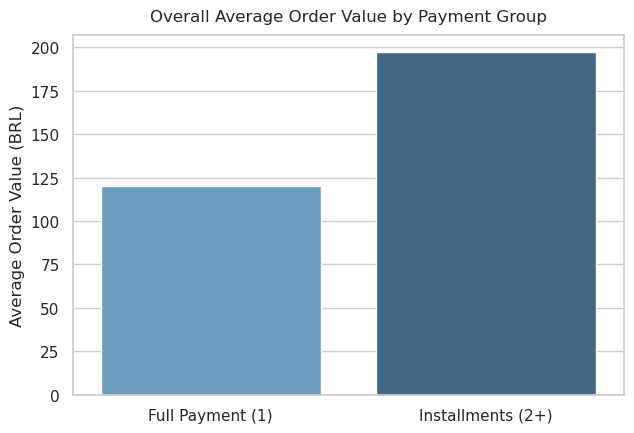

In [17]:
plt.figure(figsize=(6.5, 4.5))
sns.barplot(
    data=aov_summary,
    x='payment_type_group',
    y='average_order_value',
    hue='payment_type_group',
    palette='Blues_d',
    legend=False
)
plt.title('Overall Average Order Value by Payment Group', fontsize=12, pad=10)
plt.ylabel('Average Order Value (BRL)')
plt.xlabel('')
plt.tight_layout()
plt.show()

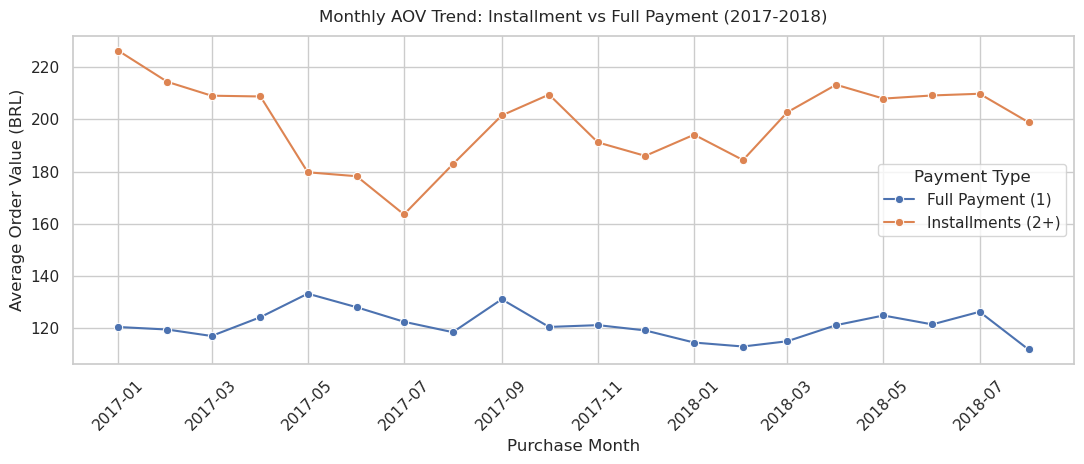

In [18]:
plt.figure(figsize=(11, 4.8))
sns.lineplot(
    data=monthly_aov,
    x='purchase_month',
    y='average_order_value',
    hue='payment_type_group',
    marker='o'
)
plt.title('Monthly AOV Trend: Installment vs Full Payment (2017-2018)', fontsize=12, pad=10)
plt.ylabel('Average Order Value (BRL)')
plt.xlabel('Purchase Month')
plt.xticks(rotation=45)
plt.legend(title='Payment Type')
plt.tight_layout()
plt.show()

> **Insight 1 Findings:**
> * **AOV Expansion:** Orders utilizing installment plans (Installments 2+) demonstrated an Average Order Value (AOV) of **197.24 BRL**, which is **+64.1% higher** than single full-payment transactions (**120.20 BRL**).
> * **Median Distribution:** Evaluating median order values to account for right-skewed transaction amounts reveals a similar premium: **134.56 BRL** for installment orders versus **79.23 BRL** for full-payment orders (**+69.8%**). This confirms that higher ticket sizes are representative of typical consumer behavior across the distribution rather than driven solely by high-value outliers.
> * **Longitudinal Consistency:** Monthly tracking indicates that installment AOV consistently outpaced full-payment AOV across all observed months. This demonstrates a robust **association** between flexible payment terms and higher basket sizes, suggesting that amortized payments lower the friction of large purchases.

### Insight 2: Customer Installment Duration Preferences
**Research Question:** Which installment durations are most frequently selected by consumers when splitting payments?  
**Methodology:** Filter to installment orders and calculate both absolute transaction volume and percentage share per duration tier.

In [19]:
df_installments = df_orders[df_orders['is_installment'] == 1].copy()

installment_distribution = (
    df_installments
    .groupby('max_installments')
    .agg(total_orders=('order_id', 'nunique'))
    .reset_index()
)

installment_distribution['percentage'] = (
    installment_distribution['total_orders'] / installment_distribution['total_orders'].sum()
) * 100
installment_distribution = installment_distribution.sort_values('max_installments')

print("=== Installment Duration Distribution ===")
display(installment_distribution.head(12))

=== Installment Duration Distribution ===


,max_installments,total_orders,percentage
0,2,12026,24.218624
1,3,10131,20.402368
2,4,6862,13.819075
3,5,5082,10.234413
4,6,3792,7.636539
5,7,1559,3.139600
6,8,4120,8.297084
7,9,618,1.244563
8,10,5137,10.345175
9,11,22,0.044305


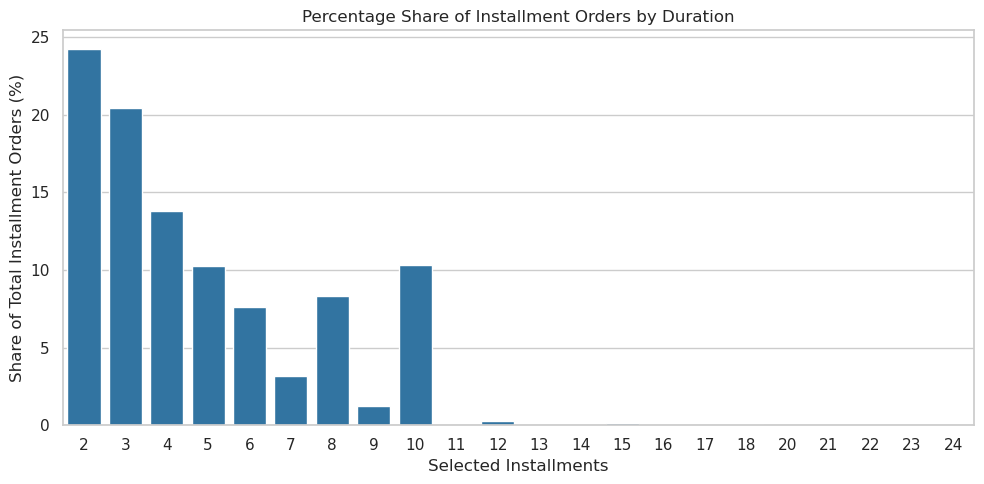

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=installment_distribution,
    x='max_installments',
    y='percentage',
    color='#1f77b4'
)
plt.title('Percentage Share of Installment Orders by Duration')
plt.xlabel('Selected Installments')
plt.ylabel('Share of Total Installment Orders (%)')
plt.tight_layout()
plt.show()

> **Insight 2 Findings:**
> * **Short-Term Concentration:** Across all 49,656 installment transactions, consumer preference concentrated heavily in short repayment windows: **2 installments (24.2%)** and **3 installments (20.4%)** together represent nearly half (**44.6%**) of total installment volume.
> * **The "10-Installment" Spike:** A distinct second mode appears at **10 installments (10.3%, 5,137 orders)**, significantly outpacing neighboring terms such as 7 (3.1%), 8 (8.3%), and 9 (1.2%). This mirrors standard Brazilian retail credit practices, where merchants and card issuers frequently market "10-month interest-free" financing thresholds.
> * **Long-Term Drop-Off:** Durations extending beyond 10 installments (11–13 months) collectively accounted for less than **0.4%** of orders, indicating diminishing customer demand for financing structures past a 10-month window.

### Insight 3: Order Value Behavior across Installment Durations
**Research Question:** Does order value vary systematically across longer installment terms?  
**Methodology:** Aggregate mean and median basket values across durations. A minimum sample size filter (`MIN_DURATION_ORDERS`) is applied to eliminate sample noise from rare installment plans.

In [21]:
MIN_DURATION_ORDERS = 100

installment_value_summary = (
    df_installments
    .groupby('max_installments')
    .agg(
        total_orders=('order_id', 'nunique'),
        mean_order_value=('total_payment_value', 'mean'),
        median_order_value=('total_payment_value', 'median')
    )
    .reset_index()
)

In [22]:
installment_value_filtered = installment_value_summary[
    installment_value_summary['total_orders'] >= MIN_DURATION_ORDERS
].copy()

print(f"=== Durations with Sample Size >= {MIN_DURATION_ORDERS} ===")
display(installment_value_filtered)

=== Durations with Sample Size >= 100 ===


,max_installments,total_orders,mean_order_value,median_order_value
0,2,12026,128.383828,111.410
1,3,10131,143.748053,112.230
2,4,6862,164.710721,117.480
3,5,5082,183.757599,126.930
4,6,3792,210.307925,139.065
5,7,1559,187.644599,140.000
6,8,4120,308.275478,212.560
7,9,618,198.782460,105.465
8,10,5137,414.196401,239.510
10,12,128,325.835781,199.770


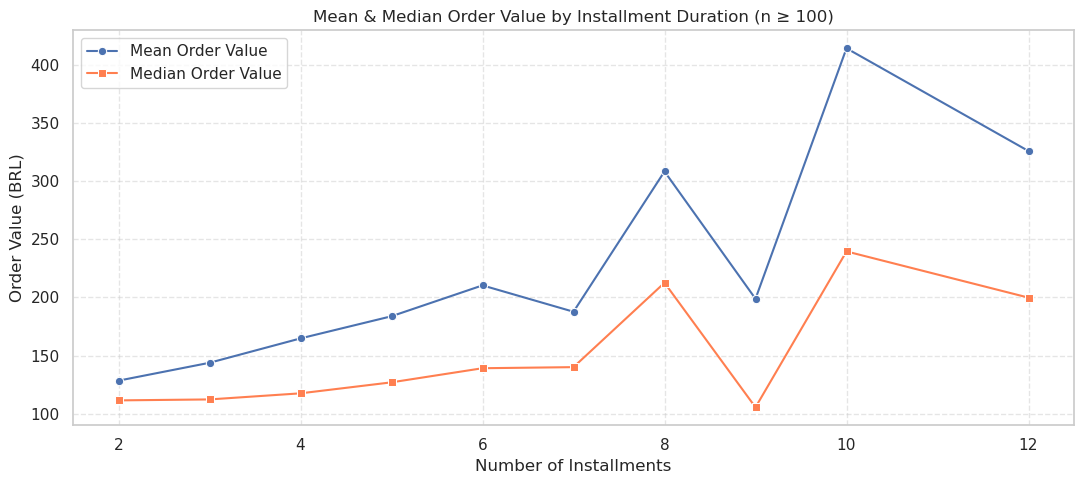

In [23]:
plt.figure(figsize=(11, 5))
sns.lineplot(
    data=installment_value_filtered,
    x='max_installments',
    y='mean_order_value',
    marker='o',
    label='Mean Order Value'
)
sns.lineplot(
    data=installment_value_filtered,
    x='max_installments',
    y='median_order_value',
    marker='s',
    label='Median Order Value',
    color='coral'
)
plt.title(f'Mean & Median Order Value by Installment Duration (n ≥ {MIN_DURATION_ORDERS})')
plt.xlabel('Number of Installments')
plt.ylabel('Order Value (BRL)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

> **Insight 3 Findings:**
> * **Positive Scaling Relationship:** Among durations meeting the minimum sample threshold ($n \ge 100$), both mean and median order values scaled upward alongside installment length.
> * **Value Dynamics Across Tiers:**
>   * 2-installment purchases averaged **128.38 BRL** (Median: 111.41 BRL).
>   * 6-installment purchases rose to **210.31 BRL** (Median: 139.07 BRL).
>   * 10-installment purchases reached **414.20 BRL** (Median: 239.51 BRL)—more than triple the order value of 2-installment baskets.
> * **Analytical Takeaway:** Consumers appear to evaluate purchases on a monthly installment affordability basis rather than the total lump sum, actively selecting longer financing durations primarily when committing to substantially larger order values.

### Insight 4: Installment Adoption Across Product Categories
**Research Question:** Which merchandise categories show the highest reliance on installment financing?  
**Methodology:** Merge items with translated category names and deduplicate at the `order_id` × `category` level to avoid artificial weighting from multi-item baskets.

In [24]:
MIN_CATEGORY_ORDERS = 100

df_category = items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)
df_category = df_category.merge(
    trans,
    on='product_category_name',
    how='left'
)

In [25]:
df_category = df_category.merge(
    df_orders[['order_id', 'is_installment']],
    on='order_id',
    how='inner'
)

In [26]:
df_category_order = df_category[
    ['order_id', 'product_category_name_english', 'is_installment']
].drop_duplicates()

In [27]:
category_summary = (
    df_category_order
    .groupby('product_category_name_english')
    .agg(
        total_orders=('order_id', 'nunique'),
        installment_orders=('is_installment', 'sum')
    )
    .reset_index()
)

category_summary['installment_pct'] = (
    category_summary['installment_orders'] / category_summary['total_orders']
) * 100

category_filtered = category_summary[
    category_summary['total_orders'] >= MIN_CATEGORY_ORDERS
].copy()

top_installment_cats = (
    category_filtered
    .sort_values('installment_pct', ascending=False)
    .head(10)
)

print("=== Top 10 Categories by Installment Share ===")
display(top_installment_cats[['product_category_name_english', 'total_orders', 'installment_pct']])

=== Top 10 Categories by Installment Share ===


,product_category_name_english,total_orders,installment_pct
14,computers,177,78.531073
70,watches_gifts,5493,67.376661
47,home_confort,392,65.051020
7,bed_bath_table,9271,63.315716
59,perfumery,3086,61.762800
53,luggage_accessories,1019,61.727184
45,home_appliances_2,227,61.674009
20,cool_stuff,3556,60.911136
31,fashion_shoes,235,60.851064
48,home_construction,483,59.420290


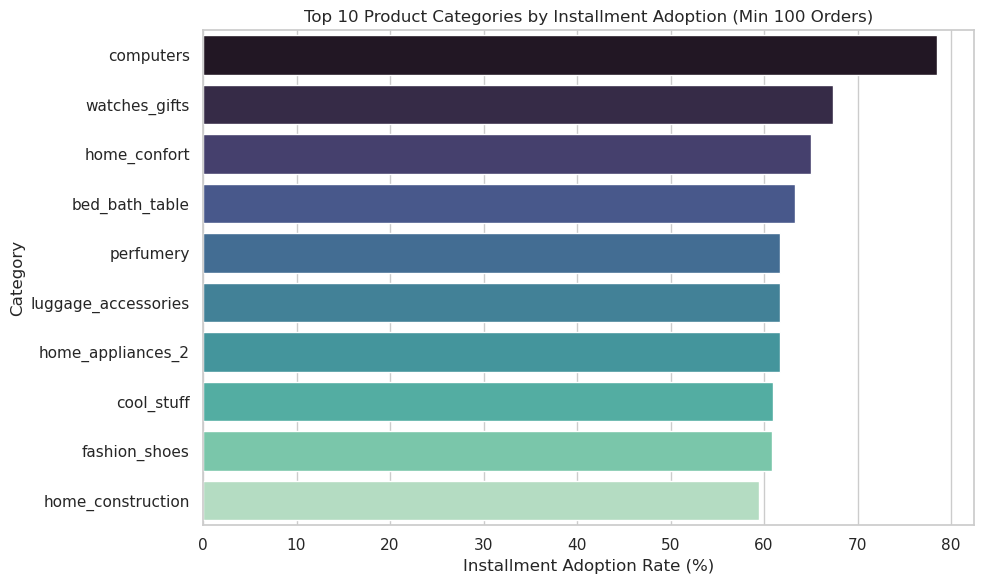

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_installment_cats,
    x='installment_pct',
    y='product_category_name_english',
    hue='product_category_name_english',
    legend=False,
    palette='mako'
)
plt.title(f'Top 10 Product Categories by Installment Adoption (Min {MIN_CATEGORY_ORDERS} Orders)')
plt.xlabel('Installment Adoption Rate (%)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

> **Insight 4 Findings:**
> * **High-Ticket Durable Goods Lead Adoption:** The highest proportions of installment adoption were observed in **Computers (78.5%)** and **Watches & Gifts (67.4%)**.
> * **Category Concentration:** Top-ranking categories predominantly comprise durable household goods and electronics, including **Home Comfort (65.1%)**, **Bed Bath & Table (63.3%)**, and **Home Appliances 2 (61.7%)**, alongside premium lifestyle accessories.
> * **Strategic Implications:** High-value durable categories show substantial reliance on credit flexibility. Joint promotions with payment partners (such as subsidized 0% interest programs or promotional installment terms) should be prioritized for these specific categories to maximize sales conversions.

### Insight 5: Repurchase Tendencies by Initial Payment Method
**Research Question:** Are customers who opt for installments on their initial purchase associated with a different repeat-purchase rate than full-payment customers?  
**Methodology:** Identify each customer's first chronological order (`customer_unique_id`), record its payment type, and track whether that customer completed subsequent transactions within the dataset window.

In [29]:
df_customer_orders = df_orders[
    [
        'customer_unique_id',
        'order_id',
        'order_purchase_timestamp',
        'payment_type_group',
        'is_installment'
    ]
].sort_values(['customer_unique_id', 'order_purchase_timestamp']).copy()

In [30]:
first_orders = (
    df_customer_orders
    .groupby('customer_unique_id', as_index=False)
    .first()
)[['customer_unique_id', 'payment_type_group', 'is_installment']]

In [31]:
customer_order_count = (
    df_customer_orders
    .groupby('customer_unique_id')
    .agg(total_orders=('order_id', 'nunique'))
    .reset_index()
)

In [32]:
repurchase_df = first_orders.merge(customer_order_count, on='customer_unique_id', how='left')
repurchase_df['is_repurchase'] = (repurchase_df['total_orders'] > 1).astype(int)

In [33]:
repurchase_summary = (
    repurchase_df
    .groupby('payment_type_group')
    .agg(
        total_customers=('customer_unique_id', 'count'),
        returning_customers=('is_repurchase', 'sum')
    )
    .reset_index()
)
repurchase_summary['repurchase_rate_pct'] = (
    repurchase_summary['returning_customers'] / repurchase_summary['total_customers']
) * 100

print("=== Repurchase Rate by First Order Payment Method ===")
display(repurchase_summary)

=== Repurchase Rate by First Order Payment Method ===


,payment_type_group,total_customers,returning_customers,repurchase_rate_pct
0,Full Payment (1),45390,1247,2.747301
1,Installments (2+),47946,1553,3.239061


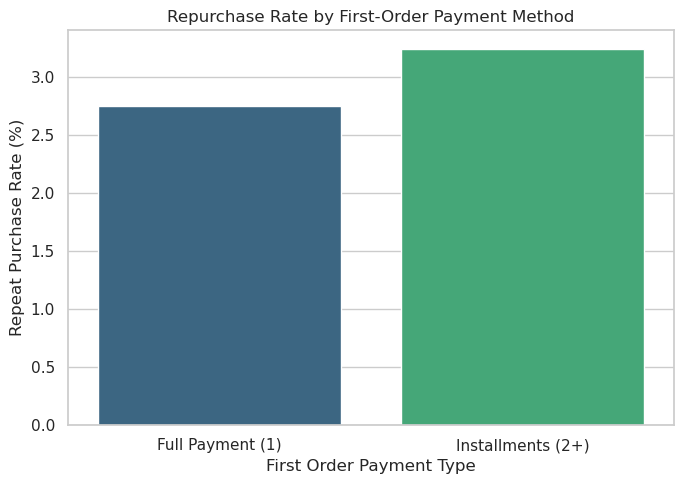

In [34]:
plt.figure(figsize=(7, 5))
sns.barplot(
    data=repurchase_summary,
    x='payment_type_group',
    y='repurchase_rate_pct',
    hue='payment_type_group',
    legend=False,
    palette='viridis'
)
plt.title('Repurchase Rate by First-Order Payment Method')
plt.ylabel('Repeat Purchase Rate (%)')
plt.xlabel('First Order Payment Type')
plt.tight_layout()
plt.show()

> **Insight 5 Findings:**
> * **Low Baseline Repurchase Frequency:** Across the platform's observational window, overall repeat purchase behavior was modest, with baseline repurchase rates falling between 2.7% and 3.2%.
> * **Marginal Variation by Payment Type:** Customers who utilized installments on their initial purchase exhibited a repeat purchase rate of **3.24%**, compared to **2.75%** for customers who paid in full (a marginal difference of +0.49 percentage points).
> * **Causality Consideration:** While installment users showed a marginally higher repeat purchase frequency, the magnitude of the difference does not provide conclusive evidence that installment access drives brand loyalty or customer retention. This aligns with Olist's marketplace aggregator model, where consumer transactions are largely need-driven rather than platform-loyal.

### Insight 6: Geographic Variation in Installment Adoption
**Research Question:** How does installment adoption distribute across Brazilian states?  
**Methodology:** Group orders by customer state and filter by minimum order volume (`MIN_STATE_ORDERS`) to avoid low-sample percentage distortion.

In [35]:
MIN_STATE_ORDERS = 500

state_summary = (
    df_orders
    .groupby('customer_state')
    .agg(
        total_orders=('order_id', 'nunique'),
        installment_orders=('is_installment', 'sum')
    )
    .reset_index()
)

state_summary['installment_pct'] = (
    state_summary['installment_orders'] / state_summary['total_orders']
) * 100

state_filtered = state_summary[
    state_summary['total_orders'] >= MIN_STATE_ORDERS
].copy()

top_states = (
    state_filtered
    .sort_values('installment_pct', ascending=False)
    .head(10)
    .reset_index(drop=True)  
)

print(f"=== Top 10 States by Installment Penetration (Orders >= {MIN_STATE_ORDERS}) ===")
display(top_states[['customer_state', 'total_orders', 'installment_pct']])

=== Top 10 States by Installment Penetration (Orders >= 500) ===


,customer_state,total_orders,installment_pct
0,PB,517,63.442940
1,CE,1278,62.754304
2,PE,1593,62.586315
3,PA,946,58.562368
4,BA,3256,58.230958
5,MA,716,56.424581
6,RJ,12348,54.640428
7,MT,886,54.401806
8,ES,1995,54.285714
9,GO,1957,54.266735


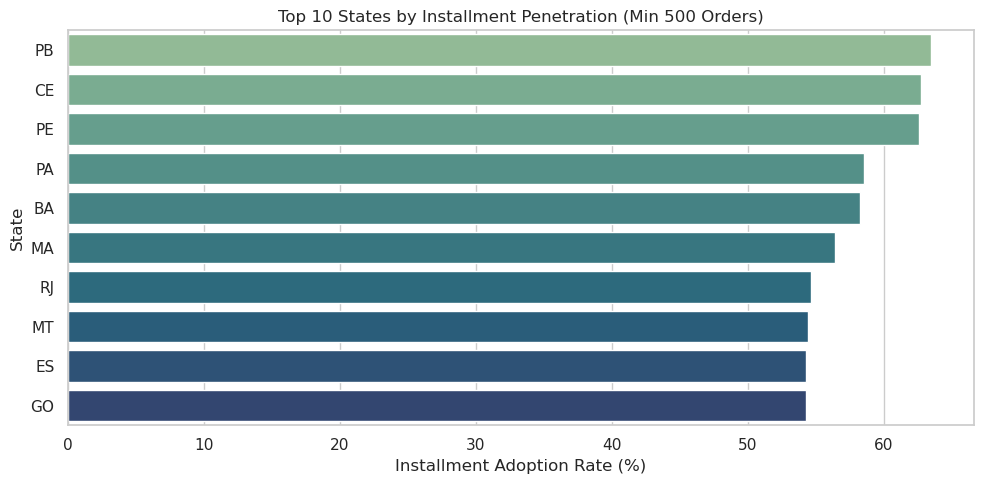

In [36]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_states,
    x='installment_pct',
    y='customer_state',
    hue='customer_state',
    legend=False,
    palette='crest'
)
plt.title(f'Top 10 States by Installment Penetration (Min {MIN_STATE_ORDERS} Orders)')
plt.xlabel('Installment Adoption Rate (%)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

> **Insight 6 Findings:**
> * **Geographic Distribution:** Controlling for sample volume ($n \ge 500$ orders), installment penetration showed clear regional clustering, with the highest adoption rates concentrated in the **Northeast region of Brazil**: **PB (Paraíba) at 63.4%**, **CE (Ceará) at 62.8%**, and **PE (Pernambuco) at 62.6%**.
> * **Socioeconomic & Logistics Dynamics:** The Northeast region lies further from the primary seller and warehouse hubs in the Southeast (e.g., São Paulo), resulting in longer transit times and higher freight overheads. Regional consumers in these states demonstrate a higher reliance on installment financing to manage aggregate landed costs.

### Insight 7: Freight Cost and Freight Burden Dynamics
**Research Question:** Are higher absolute shipping fees and higher relative freight burdens (freight as a % of landed cost) associated with increased installment usage?  
**Methodology:** Apply quartile binning on ranked values to guarantee stable quartile splits, then observe installment proportions across bins.

In [37]:
df_freight = df_orders[
    [
        'order_id',
        'is_installment',
        'total_freight_value',
        'freight_burden_pct'
    ]
].dropna().copy()

In [38]:
df_freight['freight_quartile'] = pd.qcut(
    df_freight['total_freight_value'].rank(method='first'),
    q=4,
    labels=['Q1: Low', 'Q2: Med-Low', 'Q3: Med-High', 'Q4: High']
)

df_freight['freight_burden_quartile'] = pd.qcut(
    df_freight['freight_burden_pct'].rank(method='first'),
    q=4,
    labels=['Q1: Low', 'Q2: Med-Low', 'Q3: Med-High', 'Q4: High']
)

In [39]:
freight_summary = (
    df_freight
    .groupby('freight_quartile', observed=False)
    .agg(
        total_orders=('order_id', 'count'),
        installment_rate=('is_installment', 'mean'),
        avg_freight_val=('total_freight_value', 'mean')
    )
    .reset_index()
)
freight_summary['installment_rate'] *= 100

burden_summary = (
    df_freight
    .groupby('freight_burden_quartile', observed=False)
    .agg(
        total_orders=('order_id', 'count'),
        installment_rate=('is_installment', 'mean'),
        avg_burden_pct=('freight_burden_pct', 'mean')
    )
    .reset_index()
)
burden_summary['installment_rate'] *= 100

print("=== Absolute Freight Quartiles ===")
display(freight_summary)
print("=== Freight Burden % Quartiles ===")
display(burden_summary)

=== Absolute Freight Quartiles ===


,freight_quartile,total_orders,installment_rate,avg_freight_val
0,Q1: Low,24114,40.491001,10.454654
1,Q2: Med-Low,24114,47.399851,15.460632
2,Q3: Med-High,24113,54.957907,19.787161
3,Q4: High,24114,63.075392,45.442656


=== Freight Burden % Quartiles ===


,freight_burden_quartile,total_orders,installment_rate,avg_burden_pct
0,Q1: Low,24114,66.529817,7.679881
1,Q2: Med-Low,24114,54.603135,14.892257
2,Q3: Med-High,24113,47.090781,22.505752
3,Q4: High,24114,37.700091,38.510278


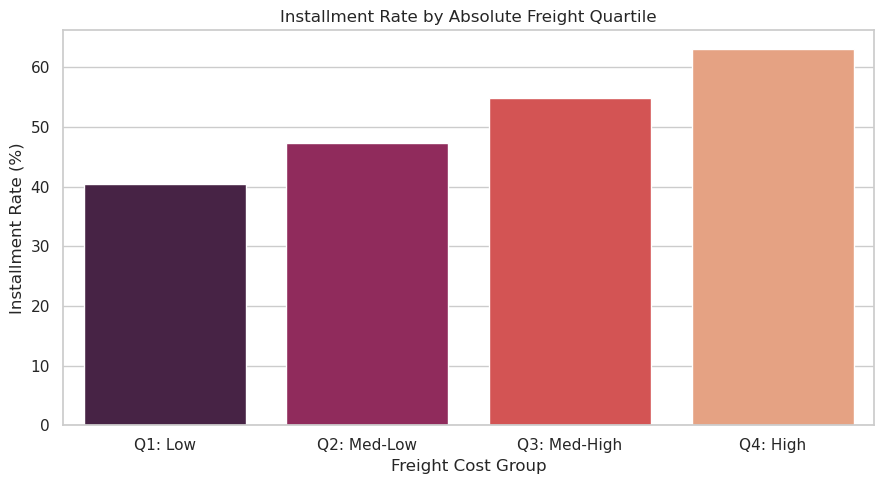

In [40]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=freight_summary,
    x='freight_quartile',
    y='installment_rate',
    hue='freight_quartile',
    palette='rocket',
    legend=False
)
plt.title('Installment Rate by Absolute Freight Quartile')
plt.ylabel('Installment Rate (%)')
plt.xlabel('Freight Cost Group')
plt.tight_layout()
plt.show()

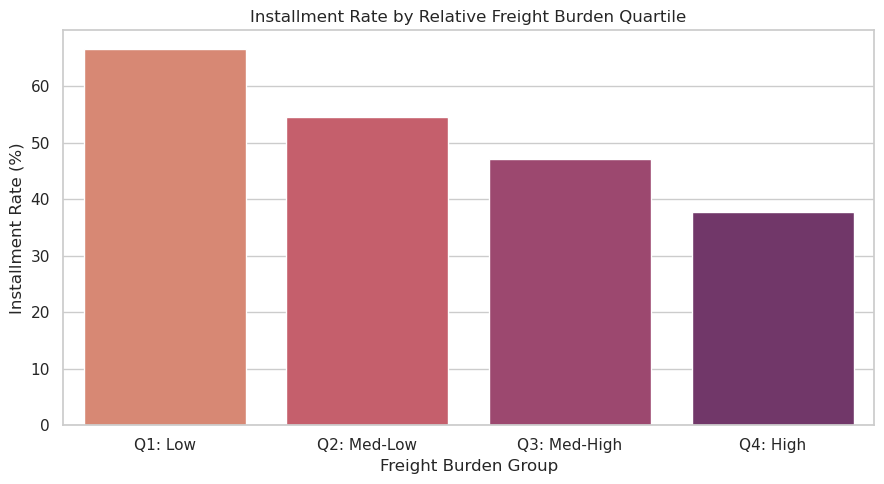

In [41]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=burden_summary,
    x='freight_burden_quartile',
    y='installment_rate',
    hue='freight_burden_quartile',
    palette='flare',
    legend=False
)
plt.title('Installment Rate by Relative Freight Burden Quartile')
plt.ylabel('Installment Rate (%)')
plt.xlabel('Freight Burden Group')
plt.tight_layout()
plt.show()

> **Insight 7 Findings:**
> * **Absolute Freight vs. Installment Rate (Positive Trend):** Segmented by absolute shipping cost quartiles, installment adoption increased monotonically:
>   * Q1 (Avg. Freight: 10.45 BRL) $\rightarrow$ **40.5%** Installment Rate
>   * Q2 (Avg. Freight: 15.46 BRL) $\rightarrow$ **47.4%** Installment Rate
>   * Q3 (Avg. Freight: 19.79 BRL) $\rightarrow$ **55.0%** Installment Rate
>   * Q4 (Avg. Freight: 45.44 BRL) $\rightarrow$ **63.1%** Installment Rate
>   *(Note: Higher absolute shipping fees are naturally correlated with heavier, bulkier, and higher-ticket merchandise).*
> * **Freight Burden % vs. Installment Rate (Inverse Pattern):** Conversely, when evaluating relative freight burden (freight value as a % of landed cost), the relationship inverted:
>   * Q1 (Lowest Burden, Avg. 7.7% of total cost) $\rightarrow$ **66.5%** Installment Rate
>   * Q4 (Highest Burden, Avg. 38.5% of total cost) $\rightarrow$ **37.7%** Installment Rate
> * **Core Takeaway:** **Base product value—rather than freight cost alone—is the primary driver of installment selection.** 
>   * Baskets with low relative freight burden typically contain high-value merchandise, prompting customers to split the total cost.
>   * Baskets with high freight burden represent low-priced items with disproportionately high shipping fees (e.g., a 20 BRL item with 15 BRL shipping); despite the high shipping ratio, the absolute monetary commitment remains small, reducing the need for credit financing.

## Executive Summary
This end-to-end analysis of 96,455 validated, delivered orders from the Olist marketplace examines consumer credit preferences, basket size dynamics, and logistical cost impacts:
1. **Financing Expands Basket Value:** Installment orders were associated with a **+64.1% higher AOV** (197.24 BRL vs. 120.20 BRL) and a **+69.8% higher median order value** compared to full payments. Higher ticket sizes systematically scaled with longer durations, culminating in a secondary volume spike at 10 installments (10.3% of financing orders).
2. **Category & Regional Heterogeneity:** Installment adoption was disproportionately concentrated in durable and high-value categories (**Computers at 78.5%**, **Watches & Gifts at 67.4%**) and in the **Northeast region of Brazil (PB, CE, PE > 62%)**.
3. **Merchandise Value Outweighs Freight Burden:** Installment usage scaled positively with absolute freight costs but negatively with relative freight burden (freight as a % of landed cost). This demonstrates that payment spreading is driven primarily by the base price of the item rather than shipping friction.

---

## Strategic Business Recommendations
1. **Threshold-Based Financing Rules:** Establish minimum order value thresholds for long-term financing (e.g., reserving 10-installment plans for carts exceeding 400 BRL). This aligns credit options with organic consumer behavior while optimizing merchant transaction fee overhead (MDR).
2. **Targeted Promotional Financing:** Focus merchant and banking partner subsidies (such as 0% interest campaigns) specifically on high-elasticity durable categories (Computers, Electronics, and Home Appliances), where consumer willingness to finance is highest.
3. **Co-Branded Shipping Subsidies in Key Geographies:** In high-penetration logistics-distressed areas like the Northeast (PB, CE, PE), pair subsidized shipping thresholds with installment options to reduce conversion drop-off on heavy items.

---

## Project Limitations
1. **Observational vs. Causal Inference:** Results represent observed empirical associations. The dataset does not include control groups or A/B testing data to prove that financing options causally generate incremental basket expansion.
2. **Time Window & Censoring:** Customer repurchase metrics are limited to the platform's ~2-year observation window, which introduces right-censoring for customers who joined late in the period and does not capture long-term customer lifetime value (CLV).
3. **Commercial Terms Unobserved:** The dataset lacks details on merchant financing arrangements, specifically whether installment interest was absorbed by sellers, subsidized by card issuers, or structured into merchant pricing.
4. **Early-Stage Data Sparsity:** Transactions from late 2016 account for less than 0.3% of the dataset, having negligible impact on overall aggregate metrics. However, due to extremely low monthly volumes causing severe AOV volatility, 2016 data was excluded specifically from the monthly trend analysis (Insight 1) to ensure a reliable longitudinal baseline.

---

## Tools & Methodology Applied
* **Data Processing & Manipulation (Pandas):** 
  Handled one-to-many relational tables by aggregating payment and item data up to an order-level grain (1 row = 1 order) to prevent metric inflation.
* **Data Integrity Checks:** 
  Utilized programmatic assertions (`assert`) to verify primary key uniqueness and monitor missing values prior to aggregation.
* **Exploratory Analysis & Segmentation:** 
  Applied rank-based quartile binning (`pd.qcut`) to handle skewed shipping data, evaluated both mean and median metrics, and filtered sample size thresholds (e.g., $n \ge 100$) to avoid percentage distortion.
* **Business Communication & Visualization (Seaborn):** 
  Framed findings around business metrics (AOV, basket size, repurchase behavior) while maintaining a strict distinction between correlation and causation.